In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
df.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
118,1010,0,1,"Beattie, Mr. Thomson",male,36.0,0,0,13050,75.2417,C6,C
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
17,909,0,3,"Assaf, Mr. Gerios",male,21.0,0,0,2692,7.2250,NaN,C
241,1133,1,2,"Christy, Mrs. (Alice Frances)",female,45.0,0,2,237789,30.0000,NaN,S


In [4]:
df = df.drop(columns = ["PassengerId", "Pclass", "Name", "Sex", "SibSp", "Parch", "Ticket", "Cabin", "Embarked"])

In [5]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [6]:
df['Age'].fillna(df['Age'].mean(), inplace = True)


C:\Users\jiyad\AppData\Local\Temp\ipykernel_5092\3839453349.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace = True)


In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        1
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
df.shape

(417, 3)

In [11]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [12]:
X = df.iloc[:, 1: 3]
y = df.iloc[:, 0]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 9)

C:\Users\jiyad\AppData\Local\Temp\ipykernel_5092\786392989.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


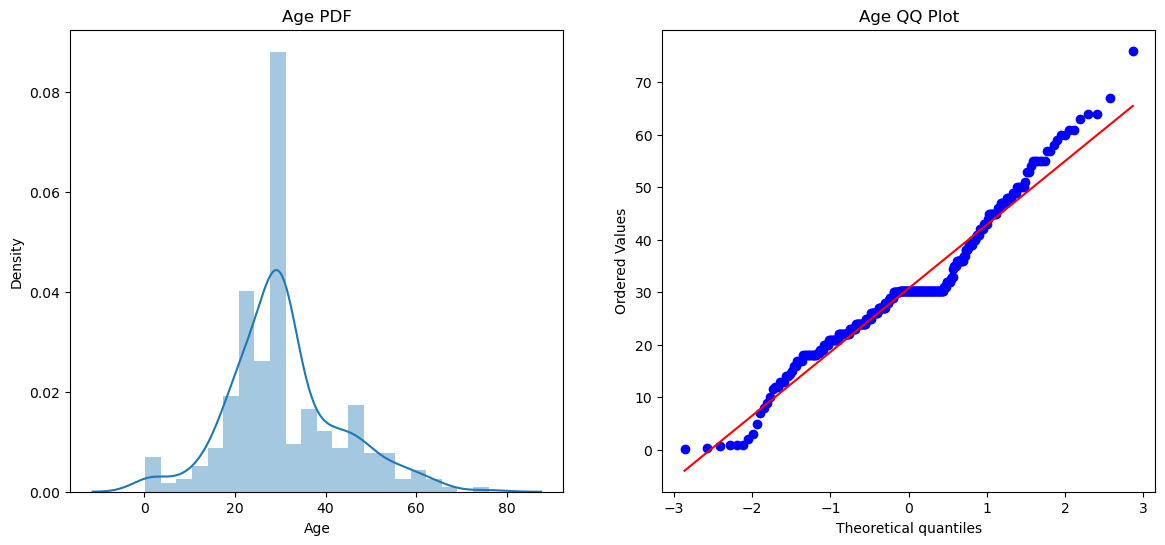

In [14]:
plt.figure(figsize = (14,6))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist = 'norm', plot = plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\jiyad\AppData\Local\Temp\ipykernel_5092\3272983381.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


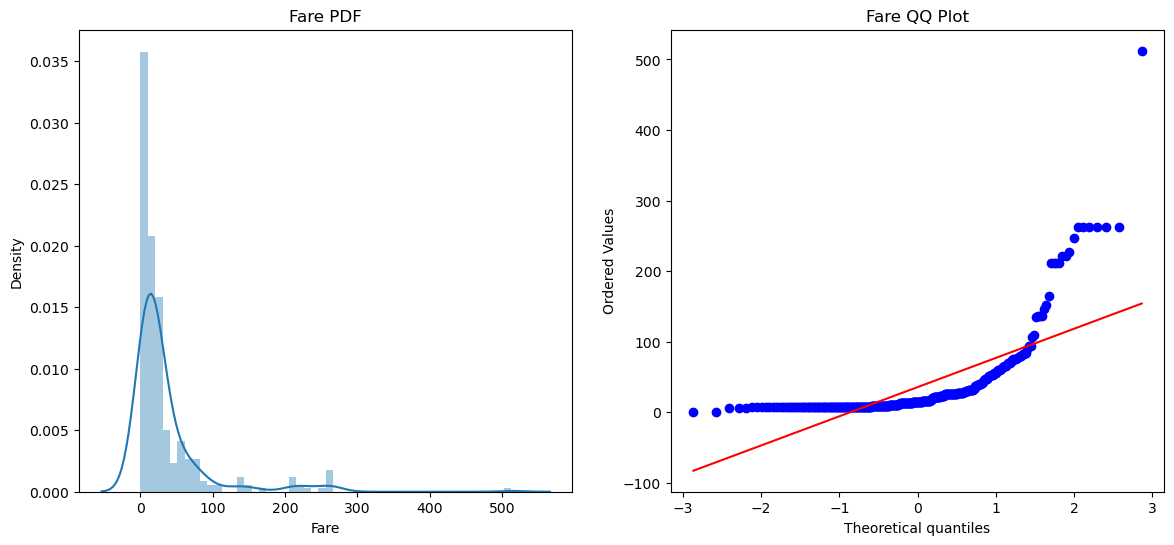

In [15]:
plt.figure(figsize = (14,6))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist = 'norm', plot = plt)
plt.title('Fare QQ Plot')

plt.show()

In [16]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [17]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

DecisionTreeClassifier()

In [18]:
y_pred =  clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

In [19]:
print("Accuracy LR :",accuracy_score(y_test, y_pred))
print("Accuracy DT :",accuracy_score(y_test, y_pred2))

Accuracy LR : 0.6666666666666666
Accuracy DT : 0.5476190476190477


In [20]:
trf = FunctionTransformer(func = np.log1p)

In [21]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [22]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred =  clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

In [23]:
print("Accuracy LR :",accuracy_score(y_test, y_pred))
print("Accuracy DT :",accuracy_score(y_test, y_pred2))

Accuracy LR : 0.5833333333333334
Accuracy DT : 0.5595238095238095


In [24]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf, X_transformed, y, scoring = 'accuracy', cv=10)))
print('DT', np.mean(cross_val_score(clf2, X_transformed, y, scoring = "accuracy", cv = 10)))

LR 0.6548780487804878
DT 0.592450638792102


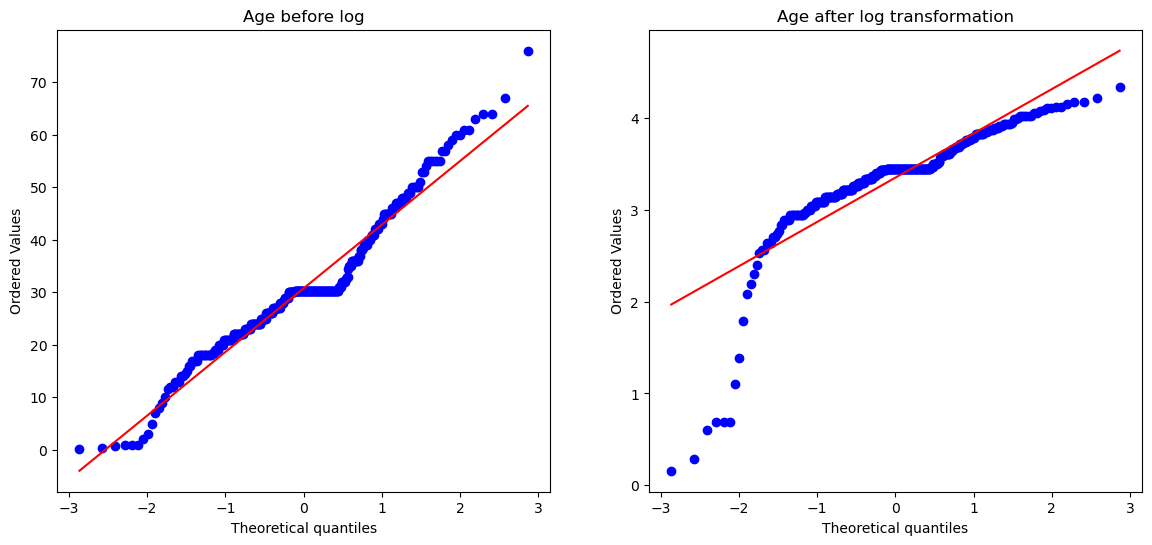

In [25]:
plt.figure(figsize = (14,6))
plt.subplot(121)
stats.probplot(X_train['Age'], dist = 'norm', plot = plt)
plt.title('Age before log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist = 'norm', plot = plt)
plt.title('Age after log transformation' )

plt.show()

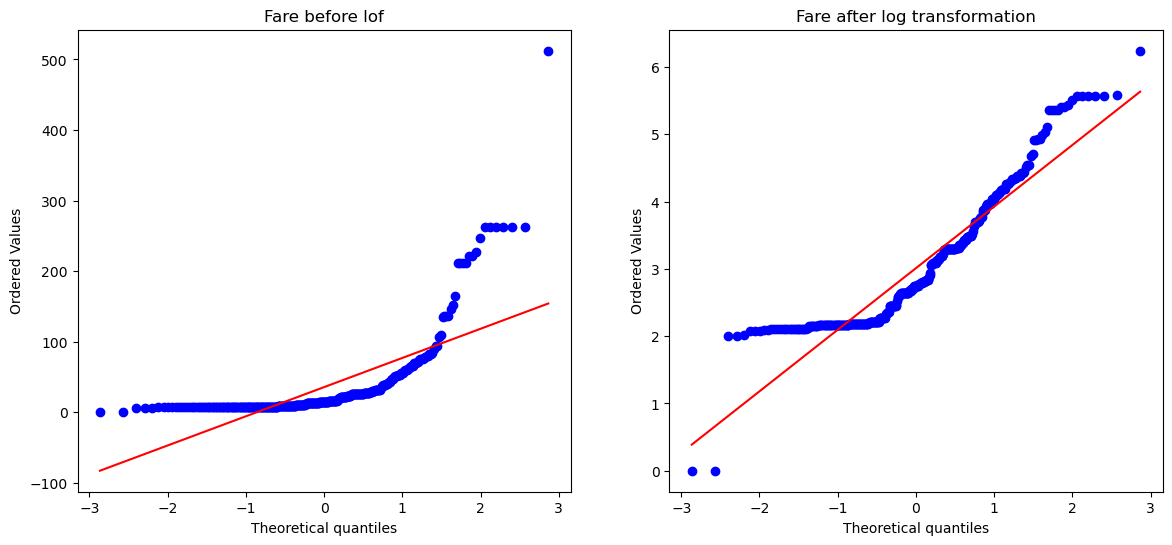

In [26]:
plt.figure(figsize = (14,6))
plt.subplot(121)
stats.probplot(X_train['Fare'], dist = 'norm', plot = plt)
plt.title('Fare before lof')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist = 'norm', plot = plt)
plt.title('Fare after log transformation')

plt.show()

In [27]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p),['Fare'])],remainder = 'passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.fit_transform(X_test)

In [28]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred =  clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

In [29]:
print("Accuracy LR :",accuracy_score(y_test, y_pred))
print("Accuracy DT :",accuracy_score(y_test, y_pred2))

Accuracy LR : 0.6071428571428571
Accuracy DT : 0.5714285714285714


In [32]:
X_transformed = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf, X_train_transformed2, y_train, scoring = 'accuracy', cv=10)))
print('DT', np.mean(cross_val_score(clf2, X_train_transformed2, y_train, scoring = "accuracy", cv = 10)))

LR 0.6542780748663103
DT 0.6156862745098041


In [47]:
def apply_transform(transform):
    X  = df.iloc[:, 1:3]
    y = df.iloc[:, 0]

    trf = ColumnTransformer([('log', FunctionTransformer(transform),['Fare'])], remainder = 'passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()
    print("Accuracy", np.mean(cross_val_score(clf,X_trans, y,scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist='norm', plot = plt)
    plt.title('Fare Before Tranform')

    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist='norm', plot = plt)
    stats.probplot(X_trans[:,0], dist = 'norm', plot = plt)
    plt.title('Fare After transform')

In [48]:
plt.show()

Accuracy 0.6354819976771197


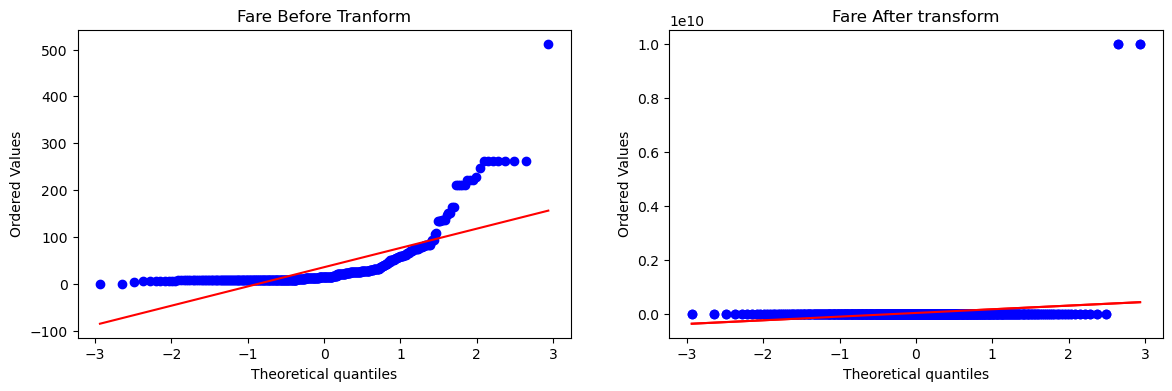

In [58]:
apply_transform(lambda X: 1/(X+0.0000000001))

Accuracy 0.6499419279907085


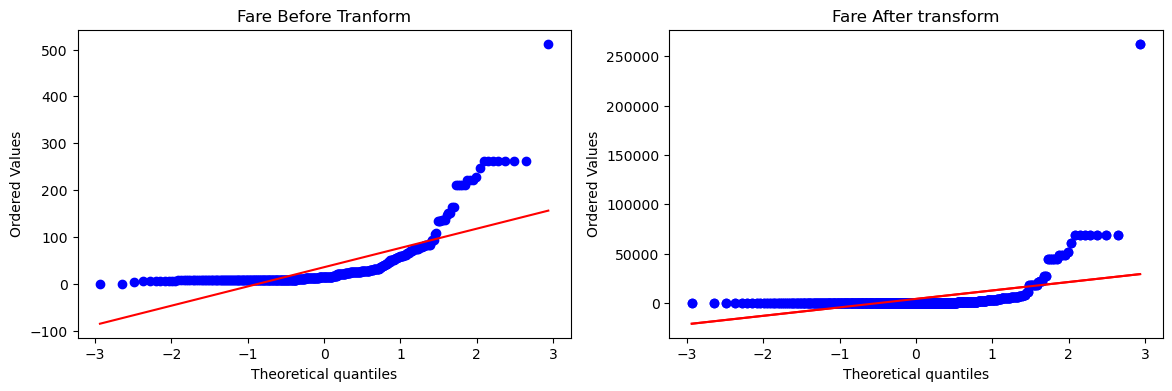

In [59]:
apply_transform(lambda X: X**2)